In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
data = pd.read_excel("../dataset/online Retail.xlsx")

In [3]:
print(data.shape)

(541909, 8)


In [4]:
print(data.info())

<class 'pandas.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  object        
 1   StockCode    541909 non-null  object        
 2   Description  540455 non-null  object        
 3   Quantity     541909 non-null  int64         
 4   InvoiceDate  541909 non-null  datetime64[us]
 5   UnitPrice    541909 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      541909 non-null  str           
dtypes: datetime64[us](1), float64(2), int64(1), object(3), str(1)
memory usage: 33.1+ MB
None


In [5]:
print(data.describe())

            Quantity                 InvoiceDate      UnitPrice     CustomerID
count  541909.000000                      541909  541909.000000  406829.000000
mean        9.552250  2011-07-04 13:34:57.156386       4.611114   15287.690570
min    -80995.000000         2010-12-01 08:26:00  -11062.060000   12346.000000
25%         1.000000         2011-03-28 11:34:00       1.250000   13953.000000
50%         3.000000         2011-07-19 17:17:00       2.080000   15152.000000
75%        10.000000         2011-10-19 11:27:00       4.130000   16791.000000
max     80995.000000         2011-12-09 12:50:00   38970.000000   18287.000000
std       218.081158                         NaN      96.759853    1713.600303


In [6]:
print(data.isnull().sum())

InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64


In [7]:
data.dropna(inplace=True)

In [8]:
print(data.isnull().sum())

InvoiceNo      0
StockCode      0
Description    0
Quantity       0
InvoiceDate    0
UnitPrice      0
CustomerID     0
Country        0
dtype: int64


In [9]:
print(data.duplicated().sum())

5225


In [10]:
data.drop_duplicates(inplace=True)

In [11]:
print(data.duplicated().sum())

0


In [12]:
print(data.shape)

(401604, 8)


In [13]:
print(data.info())

<class 'pandas.DataFrame'>
Index: 401604 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    401604 non-null  object        
 1   StockCode    401604 non-null  object        
 2   Description  401604 non-null  object        
 3   Quantity     401604 non-null  int64         
 4   InvoiceDate  401604 non-null  datetime64[us]
 5   UnitPrice    401604 non-null  float64       
 6   CustomerID   401604 non-null  float64       
 7   Country      401604 non-null  str           
dtypes: datetime64[us](1), float64(2), int64(1), object(3), str(1)
memory usage: 27.6+ MB
None


In [14]:
data.to_excel("../dataset/cleaned_output.xlsx", index=False)

In [15]:
data["Revenue"] = data["Quantity"] * data["UnitPrice"]

In [16]:
data["Revenue"].describe()

count    401604.000000
mean         20.613638
std         430.352218
min     -168469.600000
25%           4.250000
50%          11.700000
75%          19.800000
max      168469.600000
Name: Revenue, dtype: float64

In [17]:
data["Country"].value_counts().head(10)

Country
United Kingdom    356728
Germany             9480
France              8475
EIRE                7475
Spain               2528
Netherlands         2371
Belgium             2069
Switzerland         1877
Portugal            1471
Australia           1258
Name: count, dtype: int64

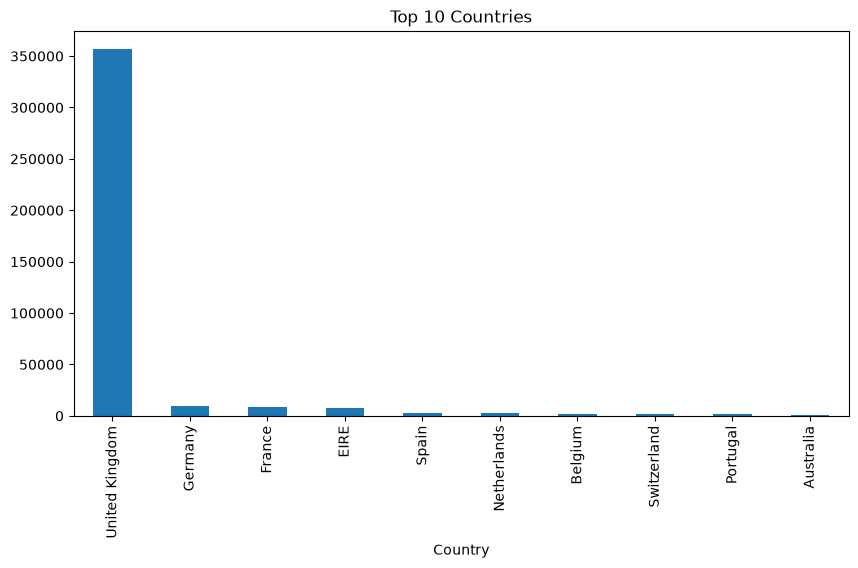

In [18]:
data["Country"].value_counts().head(10).plot(
    kind="bar",
    figsize=(10,5)
)

plt.title("Top 10 Countries")
plt.show()

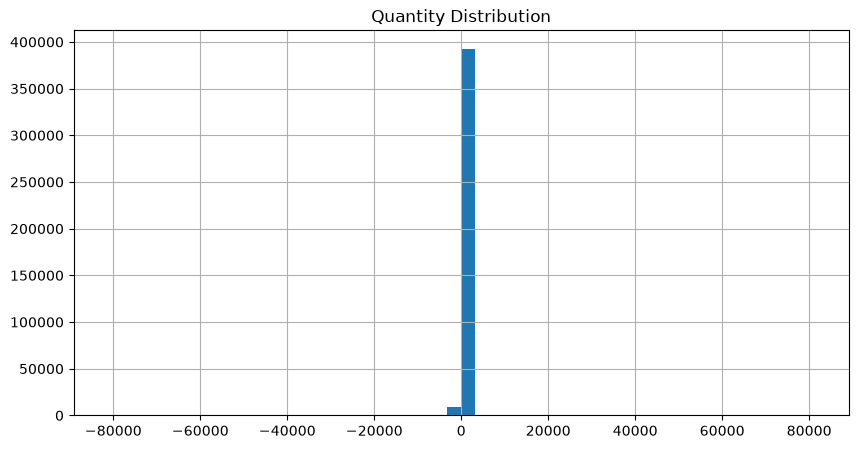

In [19]:
plt.figure(figsize=(10,5))
data["Quantity"].hist(bins=50)
plt.title("Quantity Distribution")
plt.show()

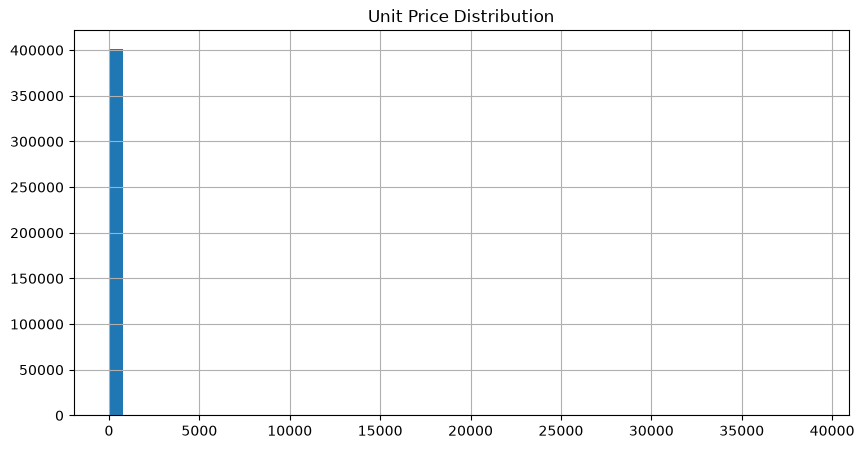

In [20]:
plt.figure(figsize=(10,5))
data["UnitPrice"].hist(bins=50)
plt.title("Unit Price Distribution")
plt.show()

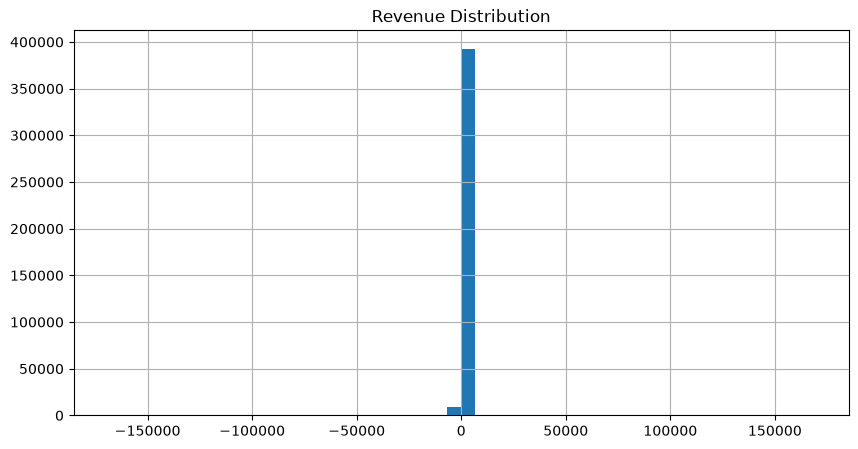

In [21]:
plt.figure(figsize=(10,5))
data["Revenue"].hist(bins=50)
plt.title("Revenue Distribution")
plt.show()

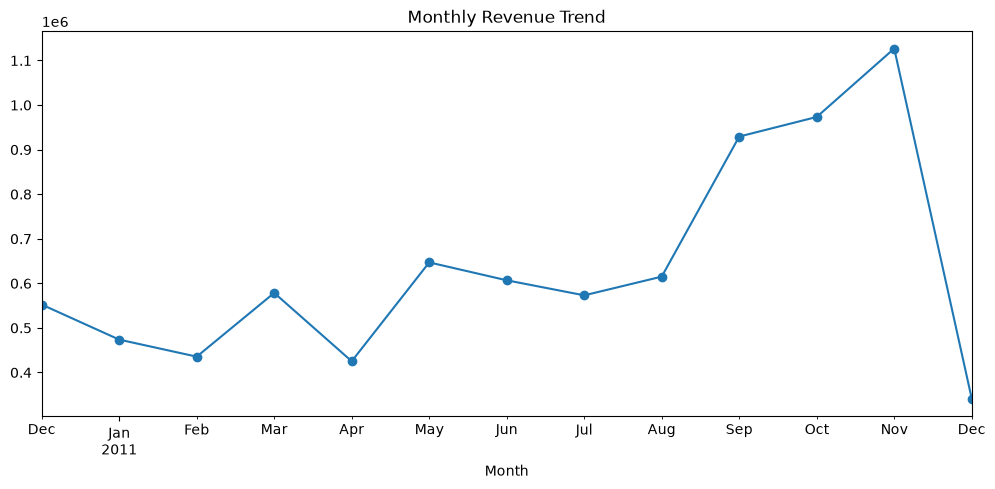

In [22]:
data["Month"] = data["InvoiceDate"].dt.to_period("M")

monthly_sales = data.groupby("Month")["Revenue"].sum()

monthly_sales.plot(
    figsize=(12,5),
    marker="o"
)

plt.title("Monthly Revenue Trend")
plt.show()

In [23]:
top_customers = (
    data.groupby("CustomerID")["Revenue"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

print(top_customers)

CustomerID
14646.0    279489.02
18102.0    256438.49
17450.0    187322.17
14911.0    132458.73
12415.0    123725.45
14156.0    113214.59
17511.0     88125.38
16684.0     65892.08
13694.0     62690.54
15311.0     59284.19
Name: Revenue, dtype: float64


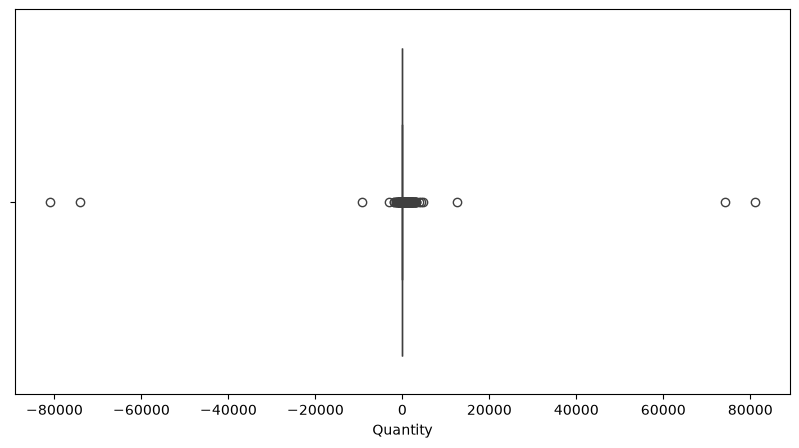

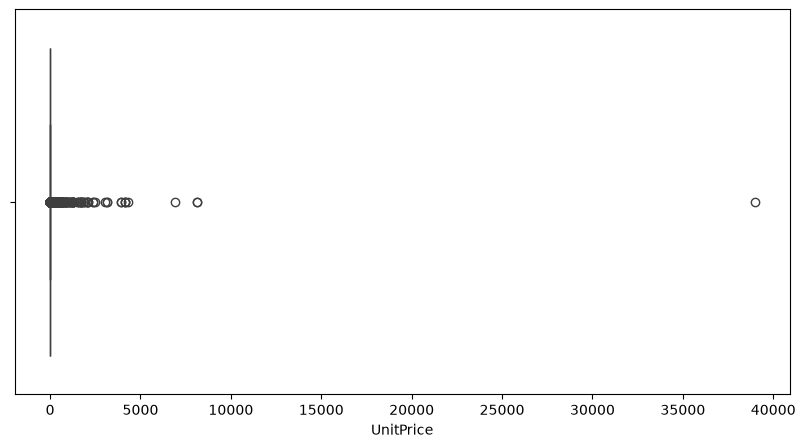

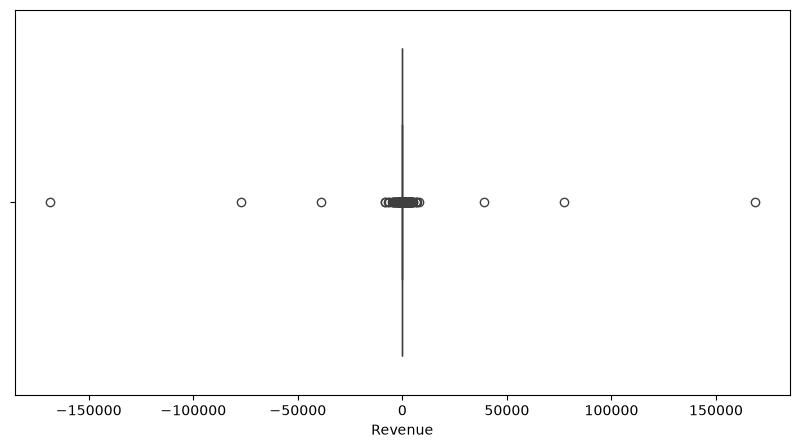

In [24]:
plt.figure(figsize=(10,5))
sns.boxplot(x=data["Quantity"])
plt.show()

plt.figure(figsize=(10,5))
sns.boxplot(x=data["UnitPrice"])
plt.show()

plt.figure(figsize=(10,5))
sns.boxplot(x=data["Revenue"])
plt.show()

In [25]:
data["Revenue"] = data["Quantity"] * data["UnitPrice"]

In [26]:
numerical_cols = data.select_dtypes(include=["int64", "float64"])

corr_matrix = numerical_cols.corr()

print(corr_matrix)

            Quantity  UnitPrice  CustomerID   Revenue
Quantity    1.000000  -0.001243   -0.003457  0.916130
UnitPrice  -0.001243   1.000000   -0.004524 -0.129311
CustomerID -0.003457  -0.004524    1.000000 -0.002130
Revenue     0.916130  -0.129311   -0.002130  1.000000


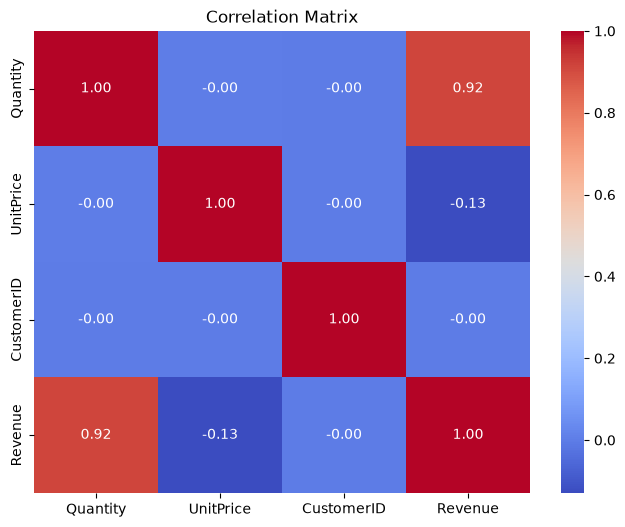

In [27]:
plt.figure(figsize=(8, 6))

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Matrix")
plt.show()

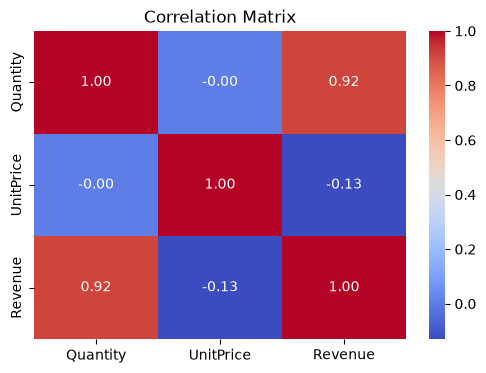

In [28]:
corr_matrix = data[
    ["Quantity", "UnitPrice", "Revenue"]
].corr()

plt.figure(figsize=(6, 4))

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Matrix")
plt.show()